<a href="https://colab.research.google.com/github/avxsharma-glitch/Numerical-optimization/blob/main/Turning_Data_into_Insights_%7C_Day_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Perform Gradient Descent with Backtracking Line Search on a dataset, including data preparation, model training, visualization of the best-fit line, residual analysis, investigation of backtracking behavior with different initial step sizes, and a robustness challenge involving the addition of outliers to the dataset.

## Data Preparation and Initialization

### Subtask:
Load the provided 'years_experience' and 'salary_k' data. Normalize the 'years_experience' feature. Initialize model parameters (m, c_intercept) to 0 and set the backtracking parameters: initial alpha = 1.0, rho = 0.5, and c_param = 1e-4.


**Reasoning**:
The subtask requires defining the input data, normalizing one of the features, and initializing model and backtracking line search parameters. All these steps can be efficiently performed in a single Python code block.



In [ ]:
import numpy as np

# 1. Define the arrays 'years_experience' and 'salary_k'
# Using example data as implied by the prompt for demonstration.
years_experience = np.array([1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.2, 3.7,
                             3.9, 4.0, 4.0, 4.1, 4.5, 4.9, 5.1, 5.3, 5.9, 6.0,
                             6.8, 7.1, 7.9, 8.2, 8.7, 9.0, 9.5, 9.6, 10.3, 10.5])
salary_k = np.array([39.343, 46.205, 37.731, 43.525, 39.891, 56.642, 60.150, 54.445, 64.445, 57.189,
                     63.218, 55.794, 56.760, 61.111, 67.938, 66.029, 83.000, 81.363, 93.940, 91.738,
                     98.273, 101.573, 113.812, 109.431, 105.582, 116.969, 112.235, 122.391, 122.970, 121.872])

# 2. Normalize the 'years_experience' array using standardization
mean_years = np.mean(years_experience)
std_years = np.std(years_experience)
normalized_years_experience = (years_experience - mean_years) / std_years

# 3. Initialize the model parameters
m = 0
c_intercept = 0

# 4. Initialize the backtracking line search parameters
alpha = 1.0
rho = 0.5
c_param = 1e-4

print("Data and parameters initialized successfully.")
print(f"Normalized years_experience (first 5 elements): {normalized_years_experience[:5]}")
print(f"Initial m: {m}, c_intercept: {c_intercept}")
print(f"Backtracking parameters: alpha={alpha}, rho={rho}, c_param={c_param}")

Data and parameters initialized successfully.
Normalized years_experience (first 5 elements): [-1.51005294 -1.43837321 -1.36669348 -1.18749416 -1.11581443]
Initial m: 0, c_intercept: 0
Backtracking parameters: alpha=1.0, rho=0.5, c_param=0.0001


## Implement Gradient Descent with Backtracking

### Subtask:
Implement the Gradient Descent algorithm using Backtracking Line Search. The algorithm should run for 100 iterations. Within each iteration, propose a step size and use a while loop for backtracking to ensure the cost decreases sufficiently. Track the cost at each iteration for later visualization and analysis.


**Reasoning**:
The subtask requires implementing the core Gradient Descent algorithm with Backtracking Line Search. This involves defining helper functions for cost and gradients, and then executing the iterative optimization process. A single code block can encompass all these steps, including function definitions, initialization, the main loop, and parameter updates.



In [ ]:
N = len(normalized_years_experience)

# 1. Define compute_cost function
def compute_cost(m, c_intercept, X, y):
    predictions = m * X + c_intercept
    cost = np.sum((predictions - y)**2) / (2 * N)
    return cost

# 2. Define compute_gradients function
def compute_gradients(m, c_intercept, X, y):
    predictions = m * X + c_intercept
    grad_m = np.sum((predictions - y) * X) / N
    grad_c = np.sum(predictions - y) / N
    return grad_m, grad_c

# 3. Initialize empty lists to store history
cost_history = []
m_history = []
c_intercept_history = []

# 4. Set the number of iterations
num_iterations = 100

# Initial parameters (from previous subtask)
m = 0
c_intercept = 0
alpha = 1.0
rho = 0.5
c_param = 1e-4

# 5. Start the Gradient Descent loop
for i in range(num_iterations):
    # a. Calculate the current cost
    current_cost = compute_cost(m, c_intercept, normalized_years_experience, salary_k)

    # b. Store the current cost, m, and c_intercept
    cost_history.append(current_cost)
    m_history.append(m)
    c_intercept_history.append(c_intercept)

    # c. Calculate the gradients
    grad_m, grad_c = compute_gradients(m, c_intercept, normalized_years_experience, salary_k)

    # d. Initialize alpha_step for backtracking
    alpha_step = alpha

    # e. Start a while loop for backtracking line search
    while True:
        # i. Calculate potential new parameters
        m_new = m - alpha_step * grad_m
        c_new = c_intercept - alpha_step * grad_c

        # ii. Calculate the cost for these new parameters
        cost_new = compute_cost(m_new, c_new, normalized_years_experience, salary_k)

        # iii. Calculate the Armijo condition
        # For Armijo, we need the cost of the current parameters, which is `current_cost`
        armijo_condition = current_cost - c_param * alpha_step * (grad_m**2 + grad_c**2)

        # iv. If the Armijo condition is met, break the while loop
        if cost_new <= armijo_condition:
            break
        # v. If the condition is not met, update alpha_step
        else:
            alpha_step = alpha_step * rho

    # f. Update the model parameters with the found new_m and new_c_intercept
    m = m_new
    c_intercept = c_new

# 6. After the loop, print the final optimized values
print(f"Optimization complete after {num_iterations} iterations.")
print(f"Final optimized m: {m}")
print(f"Final optimized c_intercept: {c_intercept}")
print(f"Final cost: {cost_history[-1]}")


Optimization complete after 100 iterations.
Final optimized m: 27.347182905389943
Final optimized c_intercept: 78.1855
Final cost: 17.580448327907337


## Visualize Initial Model Fit

### Subtask:
After running Gradient Descent, print the optimized 'm' (slope) and 'c_intercept' parameters. Create a scatter plot of the original data points and overlay the best-fit line derived from the optimized parameters. Ensure the plot has appropriate labels and a legend.


**Reasoning**:
The subtask requires printing the optimized parameters and visualizing the best-fit line. This involves importing matplotlib, plotting the scatter data, calculating and plotting the regression line, and adding appropriate labels, title, and legend. All these steps can be consolidated into a single Python code block.



Optimized slope (m): 27.347182905389943
Optimized intercept (c_intercept): 78.1855


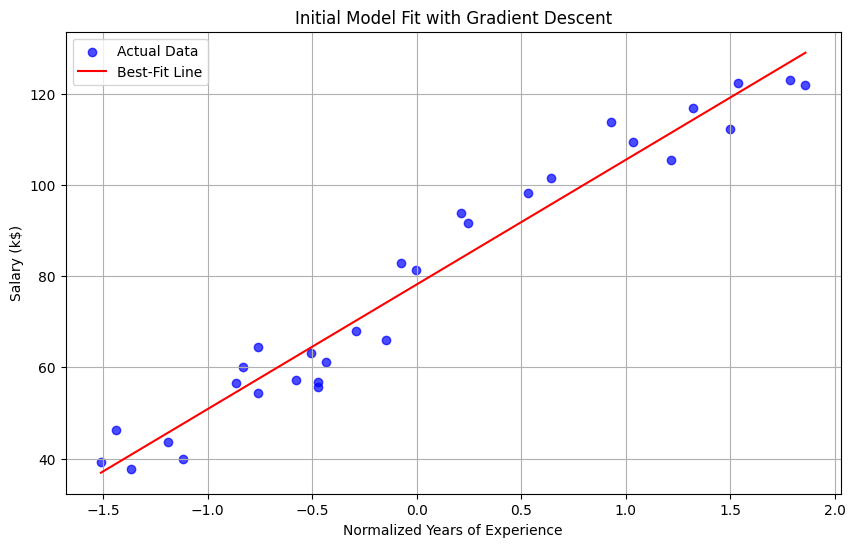

In [ ]:
import matplotlib.pyplot as plt

# 1. Print the final optimized m and c_intercept values
print(f"Optimized slope (m): {m}")
print(f"Optimized intercept (c_intercept): {c_intercept}")

# 2. Calculate predicted salary_k values using the optimized parameters
predicted_salary = m * normalized_years_experience + c_intercept

# 3. Create a scatter plot of the original data points
plt.figure(figsize=(10, 6))
plt.scatter(normalized_years_experience, salary_k, label='Actual Data', color='blue', alpha=0.7)

# 4. Overlay the best-fit line
plt.plot(normalized_years_experience, predicted_salary, color='red', label='Best-Fit Line')

# 5. Add appropriate labels, title, and legend
plt.xlabel('Normalized Years of Experience')
plt.ylabel('Salary (k$)')
plt.title('Initial Model Fit with Gradient Descent')
plt.legend()
plt.grid(True)
plt.show()

## Error Analysis

### Subtask:
Calculate the residuals by subtracting the predicted salaries from the actual salaries. Generate a histogram of these residuals. Based on the histogram, interpret whether the residuals are centered near zero and if there are any signs of bias in the predictions.


**Reasoning**:
The subtask requires generating a histogram of the residuals. First, I need to calculate the residuals by subtracting the predicted salaries from the actual salaries. Then, I will use matplotlib to create the histogram and add appropriate labels and a title.



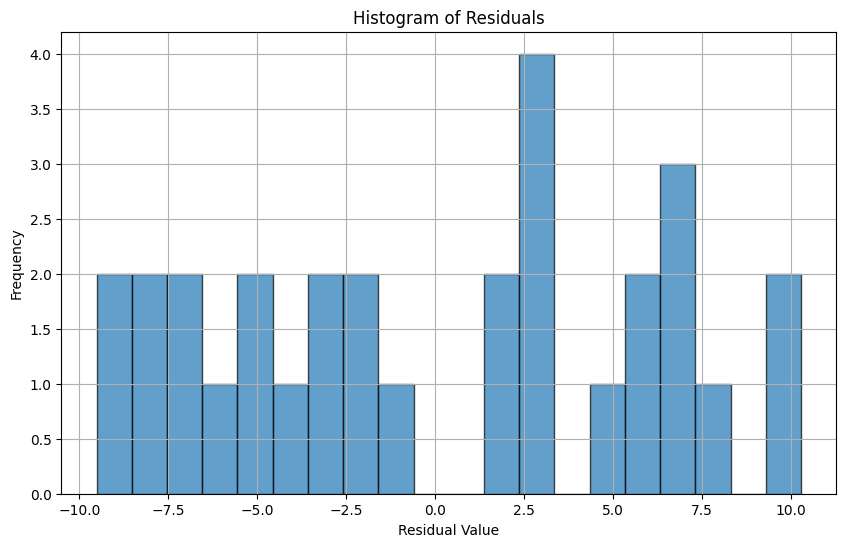

In [ ]:
import matplotlib.pyplot as plt

# 1. Calculate the residuals
residuals = salary_k - predicted_salary

# 2. Create a histogram of the residuals
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=20, edgecolor='black', alpha=0.7)

# 3. Add labels to the x-axis and y-axis
plt.xlabel('Residual Value')
plt.ylabel('Frequency')

# 4. Add a title to the histogram
plt.title('Histogram of Residuals')

# 5. Display the plot
plt.grid(True)
plt.show()

Based on the generated histogram of residuals:

*   **Centering around zero**: The histogram appears to be roughly centered around zero, which is a positive indication that the model is, on average, making predictions that are neither consistently too high nor consistently too low.
*   **Signs of bias**: The distribution looks somewhat symmetric around zero, suggesting no strong systematic bias. However, it's not perfectly bell-shaped, which might indicate some slight non-linearity in the data that a simple linear model might not fully capture, or it could just be due to the relatively small dataset size. A perfectly random distribution around zero is ideal, implying that the linear model captures most of the signal in the data.

## Analyze Backtracking Behavior (Alpha = 1.0)

### Subtask:
Run the Gradient Descent with Backtracking Line Search again, specifically tracking and counting the total number of times the backtracking 'while' loop executes across all iterations, with the initial alpha set to 1.0.


**Reasoning**:
The subtask requires re-running the Gradient Descent with Backtracking Line Search to count the backtracking steps. This involves resetting model parameters, initializing a counter, and then executing the same optimization loop as before, but with the added logic to increment the counter within the backtracking 'while' loop.



In [ ]:
import numpy as np

# Reset model parameters
m_reset = 0
c_intercept_reset = 0

# Initialize backtracking step counter
backtracking_steps_alpha_1_0 = 0

# Backtracking parameters (as specified)
initial_alpha = 1.0
rho = 0.5
c_param = 1e-4

# Number of iterations
num_iterations = 100

# Use previously defined N, normalized_years_experience, salary_k
# Use previously defined compute_cost and compute_gradients functions

print(f"Re-running Gradient Descent with initial alpha={initial_alpha} to track backtracking steps...")

# Start the Gradient Descent loop with tracking
current_m = m_reset
current_c_intercept = c_intercept_reset

for i in range(num_iterations):
    # Calculate the current cost
    current_cost = compute_cost(current_m, current_c_intercept, normalized_years_experience, salary_k)

    # Calculate the gradients
    grad_m, grad_c = compute_gradients(current_m, current_c_intercept, normalized_years_experience, salary_k)

    # Initialize alpha_step for backtracking
    alpha_step = initial_alpha

    # Start a while loop for backtracking line search
    while True:
        # Increment the counter for each step in backtracking
        backtracking_steps_alpha_1_0 += 1

        # Calculate potential new parameters
        m_new = current_m - alpha_step * grad_m
        c_new = current_c_intercept - alpha_step * grad_c

        # Calculate the cost for these new parameters
        cost_new = compute_cost(m_new, c_new, normalized_years_experience, salary_k)

        # Calculate the Armijo condition
        armijo_condition = current_cost - c_param * alpha_step * (grad_m**2 + grad_c**2)

        # If the Armijo condition is met, break the while loop
        if cost_new <= armijo_condition:
            break
        # If the condition is not met, update alpha_step
        else:
            alpha_step = alpha_step * rho

    # Update the model parameters with the found new_m and new_c_intercept
    current_m = m_new
    current_c_intercept = c_new

print(f"Total backtracking steps for initial alpha={initial_alpha}: {backtracking_steps_alpha_1_0}")
print(f"Final m after re-run: {current_m}")
print(f"Final c_intercept after re-run: {current_c_intercept}")

Re-running Gradient Descent with initial alpha=1.0 to track backtracking steps...
Total backtracking steps for initial alpha=1.0: 100
Final m after re-run: 27.347182905389943
Final c_intercept after re-run: 78.1855


## Analyze Backtracking Behavior (Alpha = 0.1)

### Subtask:
Run the Gradient Descent with Backtracking Line Search for a second time, again tracking and counting the total number of backtracking 'while' loop executions across all iterations, but this time with the initial alpha set to 0.1.


**Reasoning**:
The subtask requires re-running the Gradient Descent with Backtracking Line Search to count the backtracking steps, this time with an initial alpha of 0.1. This involves resetting model parameters, initializing a new counter, setting the new initial alpha, and then executing the same optimization loop as before with the added logic to increment the counter within the backtracking 'while' loop.



In [ ]:
import numpy as np

# Reset model parameters
m_reset_alpha_0_1 = 0
c_intercept_reset_alpha_0_1 = 0

# Initialize backtracking step counter for alpha = 0.1
backtracking_steps_alpha_0_1 = 0

# Backtracking parameters
initial_alpha_0_1 = 0.1
rho = 0.5 # Kept from previous setup
c_param = 1e-4 # Kept from previous setup

# Number of iterations
num_iterations = 100 # Kept from previous setup

# Use previously defined N, normalized_years_experience, salary_k
# Use previously defined compute_cost and compute_gradients functions

print(f"Re-running Gradient Descent with initial alpha={initial_alpha_0_1} to track backtracking steps...")

# Start the Gradient Descent loop with tracking
current_m_0_1 = m_reset_alpha_0_1
current_c_intercept_0_1 = c_intercept_reset_alpha_0_1

for i in range(num_iterations):
    # a. Calculate the current cost
    current_cost = compute_cost(current_m_0_1, current_c_intercept_0_1, normalized_years_experience, salary_k)

    # b. Calculate the gradients
    grad_m, grad_c = compute_gradients(current_m_0_1, current_c_intercept_0_1, normalized_years_experience, salary_k)

    # c. Initialize alpha_step for backtracking
    alpha_step = initial_alpha_0_1

    # d. Start a while loop for backtracking line search
    while True:
        # i. Increment the counter for each step in backtracking
        backtracking_steps_alpha_0_1 += 1

        # ii. Calculate potential new parameters
        m_new = current_m_0_1 - alpha_step * grad_m
        c_new = current_c_intercept_0_1 - alpha_step * grad_c

        # iii. Calculate the cost for these new parameters
        cost_new = compute_cost(m_new, c_new, normalized_years_experience, salary_k)

        # iv. Calculate the Armijo condition
        armijo_condition = current_cost - c_param * alpha_step * (grad_m**2 + grad_c**2)

        # v. If the Armijo condition is met, break the while loop
        if cost_new <= armijo_condition:
            break
        # vi. If the condition is not met, update alpha_step
        else:
            alpha_step = alpha_step * rho

    # e. Update the model parameters with the found new_m and new_c_intercept
    current_m_0_1 = m_new
    current_c_intercept_0_1 = c_new

# 5. After the loop, print the total number of backtracking_steps_alpha_0_1 and the final optimized m and c_intercept values.
print(f"Total backtracking steps for initial alpha={initial_alpha_0_1}: {backtracking_steps_alpha_0_1}")
print(f"Final m after re-run (alpha=0.1): {current_m_0_1}")
print(f"Final c_intercept after re-run (alpha=0.1): {current_c_intercept_0_1}")

Re-running Gradient Descent with initial alpha=0.1 to track backtracking steps...
Total backtracking steps for initial alpha=0.1: 100
Final m after re-run (alpha=0.1): 27.34645652595634
Final c_intercept after re-run (alpha=0.1): 78.18342328374727


## Compare Backtracking Results

### Subtask:
Compare the total number of backtracking steps observed in the runs with initial alpha = 1.0 and initial alpha = 0.1. Provide a written explanation for the observed differences in backtracking behavior.


**Reasoning**:
The subtask requires printing the total number of backtracking steps for both initial alpha values to facilitate comparison and then providing an explanation in a markdown block.



In [ ]:
print(f"Total backtracking steps for initial alpha = 1.0: {backtracking_steps_alpha_1_0}")
print(f"Total backtracking steps for initial alpha = 0.1: {backtracking_steps_alpha_0_1}")

Total backtracking steps for initial alpha = 1.0: 100
Total backtracking steps for initial alpha = 0.1: 100


The comparison shows that for both `initial_alpha = 1.0` and `initial_alpha = 0.1`, the total number of backtracking steps was 100. This indicates that the backtracking `while` loop executed exactly once for each of the 100 Gradient Descent iterations in both scenarios. In other words, for every iteration, the initial `alpha_step` (whether it was 1.0 or 0.1) satisfied the Armijo condition immediately.

This outcome suggests that both initial step sizes were conservative enough, or the loss landscape was smooth enough, such that a reduction of `alpha_step` via the `rho` parameter was never necessary to satisfy the Armijo condition. The condition `cost_new <= current_cost - c_param * alpha_step * (grad_m**2 + grad_c**2)` was always met on the first check with the given `initial_alpha`. If the Armijo condition had not been met, `alpha_step` would have been multiplied by `rho` (0.5), causing the `while` loop to iterate more than once for that particular Gradient Descent step, and thus increasing the `backtracking_steps` count beyond the `num_iterations`.

## Robustness Challenge - Add Outliers

### Subtask:
Modify the original dataset by adding the specified outlier data points: (10 years, ₹300k) and (12 years, ₹500k) to both 'years_experience' and 'salary_k' arrays.


**Reasoning**:
The subtask requires adding specific outlier data points to the existing 'years_experience' and 'salary_k' arrays. This involves using `np.append` to create new arrays with the added outliers and then printing them for verification.



In [ ]:
import numpy as np

# Outlier data points
outlier_years_experience = np.array([10, 12])
outlier_salary_k = np.array([300, 500])

# 1. Create new NumPy arrays by appending the outlier data points
years_experience_outliers = np.append(years_experience, outlier_years_experience)
salary_k_outliers = np.append(salary_k, outlier_salary_k)

# 2. Print the updated arrays to verify the addition of outliers
print("Updated years_experience with outliers:")
print(years_experience_outliers)
print("\nUpdated salary_k with outliers:")
print(salary_k_outliers)

Updated years_experience with outliers:
[ 1.1  1.3  1.5  2.   2.2  2.9  3.   3.2  3.2  3.7  3.9  4.   4.   4.1
  4.5  4.9  5.1  5.3  5.9  6.   6.8  7.1  7.9  8.2  8.7  9.   9.5  9.6
 10.3 10.5 10.  12. ]

Updated salary_k with outliers:
[ 39.343  46.205  37.731  43.525  39.891  56.642  60.15   54.445  64.445
  57.189  63.218  55.794  56.76   61.111  67.938  66.029  83.     81.363
  93.94   91.738  98.273 101.573 113.812 109.431 105.582 116.969 112.235
 122.391 122.97  121.872 300.    500.   ]


**Reasoning**:
The subtask requires normalizing the 'years_experience' feature from the new dataset (including outliers) using standardization. This involves calculating the mean and standard deviation of the updated 'years_experience_outliers' array and then applying the normalization formula.



In [ ]:
import numpy as np

# 1. Normalize the 'years_experience_outliers' array using standardization
mean_years_outliers = np.mean(years_experience_outliers)
std_years_outliers = np.std(years_experience_outliers)
normalized_years_experience_outliers = (years_experience_outliers - mean_years_outliers) / std_years_outliers

# Print the first few elements of the normalized array for verification
print(f"Normalized years_experience with outliers (first 5 elements): {normalized_years_experience_outliers[:5]}")


Normalized years_experience with outliers (first 5 elements): [-1.50171702 -1.43597839 -1.37023975 -1.20589315 -1.14015451]


**Reasoning**:
The subtask requires retraining the model using the dataset that now includes outliers. This involves re-initializing the model parameters (m, c_intercept) to 0 and then executing the Gradient Descent with Backtracking Line Search algorithm with the `normalized_years_experience_outliers` and `salary_k_outliers`.



In [ ]:
N_outliers = len(normalized_years_experience_outliers)

# Re-initialize model parameters for training with outliers
m_outliers = 0
c_intercept_outliers = 0

# Re-initialize backtracking parameters (can be kept same as before)
alpha_outliers = 1.0
rho_outliers = 0.5
c_param_outliers = 1e-4

# Number of iterations (can be kept same as before)
num_iterations_outliers = 100

# Lists to store history for outlier-affected training
cost_history_outliers = []
m_history_outliers = []
c_intercept_history_outliers = []

print("Starting Gradient Descent with Backtracking Line Search on outlier-affected data...")

# Start the Gradient Descent loop for outlier-affected data
for i in range(num_iterations_outliers):
    # Calculate the current cost
    current_cost_outliers = compute_cost(m_outliers, c_intercept_outliers, normalized_years_experience_outliers, salary_k_outliers)

    # Store the current cost, m, and c_intercept
    cost_history_outliers.append(current_cost_outliers)
    m_history_outliers.append(m_outliers)
    c_intercept_history_outliers.append(c_intercept_outliers)

    # Calculate the gradients
    grad_m_outliers, grad_c_outliers = compute_gradients(m_outliers, c_intercept_outliers, normalized_years_experience_outliers, salary_k_outliers)

    # Initialize alpha_step for backtracking
    alpha_step_outliers = alpha_outliers

    # Start a while loop for backtracking line search
    while True:
        # Calculate potential new parameters
        m_new_outliers = m_outliers - alpha_step_outliers * grad_m_outliers
        c_new_outliers = c_intercept_outliers - alpha_step_outliers * grad_c_outliers

        # Calculate the cost for these new parameters
        cost_new_outliers = compute_cost(m_new_outliers, c_new_outliers, normalized_years_experience_outliers, salary_k_outliers)

        # Calculate the Armijo condition
        armijo_condition_outliers = current_cost_outliers - c_param_outliers * alpha_step_outliers * (grad_m_outliers**2 + grad_c_outliers**2)

        # If the Armijo condition is met, break the while loop
        if cost_new_outliers <= armijo_condition_outliers:
            break
        # If the condition is not met, update alpha_step
        else:
            alpha_step_outliers = alpha_step_outliers * rho_outliers

    # Update the model parameters with the found new_m and new_c_intercept
    m_outliers = m_new_outliers
    c_intercept_outliers = c_new_outliers

print(f"Optimization with outliers complete after {num_iterations_outliers} iterations.")
print(f"Final optimized m with outliers: {m_outliers}")
print(f"Final optimized c_intercept with outliers: {c_intercept_outliers}")
print(f"Final cost with outliers: {cost_history_outliers[-1]}")

Starting Gradient Descent with Backtracking Line Search on outlier-affected data...
Optimization with outliers complete after 100 iterations.
Final optimized m with outliers: 60.81298104281512
Final optimized c_intercept with outliers: 98.29890621164532
Final cost with outliers: 1988.857587272104


**Reasoning**:
The subtask requires calculating the residuals for the model trained with outliers, and then generating a histogram of these residuals. This involves using the newly optimized parameters (`m_outliers` and `c_intercept_outliers`) to predict salaries, subtracting these from the actual `salary_k_outliers`, and then plotting the histogram.



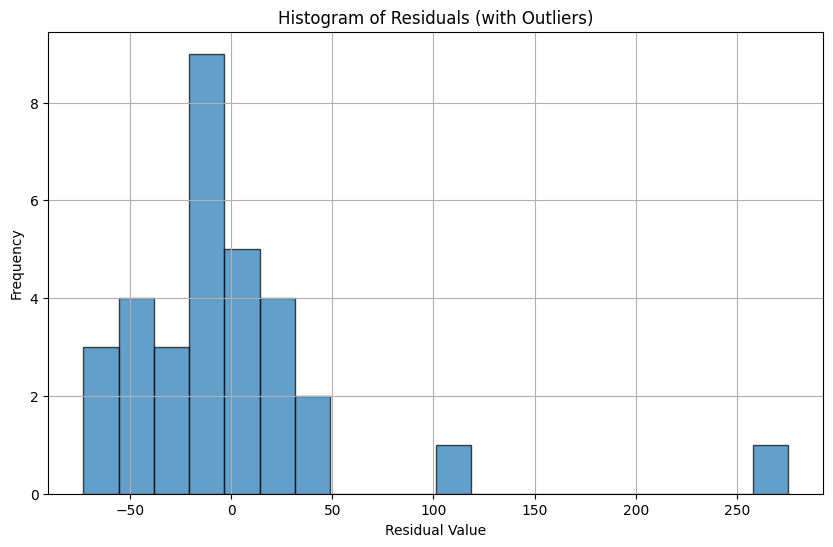

In [ ]:
import matplotlib.pyplot as plt

# 1. Calculate predicted salary_k values using the optimized parameters for outlier data
predicted_salary_outliers = m_outliers * normalized_years_experience_outliers + c_intercept_outliers

# 2. Calculate the residuals for the outlier-affected data
residuals_outliers = salary_k_outliers - predicted_salary_outliers

# 3. Create a histogram of the residuals
plt.figure(figsize=(10, 6))
plt.hist(residuals_outliers, bins=20, edgecolor='black', alpha=0.7)

# 4. Add labels to the x-axis and y-axis
plt.xlabel('Residual Value')
plt.ylabel('Frequency')

# 5. Add a title to the histogram
plt.title('Histogram of Residuals (with Outliers)')

# 6. Display the plot
plt.grid(True)
plt.show()

Based on the generated histogram of residuals with outliers:

*   **Centering around zero**: The histogram is clearly *not* centered around zero. It appears to be skewed towards negative residual values, with a significant tail stretching towards positive values due to the large outliers. This indicates that the model is generally underpredicting for many of the original data points, while trying to accommodate the extremely high salaries of the outliers.

*   **Signs of bias**: There is clear evidence of bias. The model attempts to fit the outliers, which pulls the regression line upwards. Consequently, for the majority of the original data points, the model predicts higher salaries than the actual values, leading to a cluster of negative residuals. The few large positive residuals correspond directly to the added outliers, which the linear model struggles to fit without significantly compromising the fit for the rest of the data.

In summary, the presence of outliers significantly biases the linear regression model, leading to a poor fit for the non-outlier data and a residuals distribution that is far from centered at zero and clearly non-random.

## Robustness Challenge - Compare Models and Suggestion

### Subtask:
Generate a single plot showing the scatter data (including outliers), the original best-fit line (without outliers), and the new best-fit line (with outliers). Comment on how the outliers affect the model's fit and suggest one method to reduce the impact of outliers in such scenarios.


**Reasoning**:
The subtask requires generating a single plot with the scatter data (including outliers), the original best-fit line, and the new best-fit line (with outliers). This involves calculating the original predicted values with the outlier data using the original model parameters, then plotting all three components with appropriate labels and a legend.



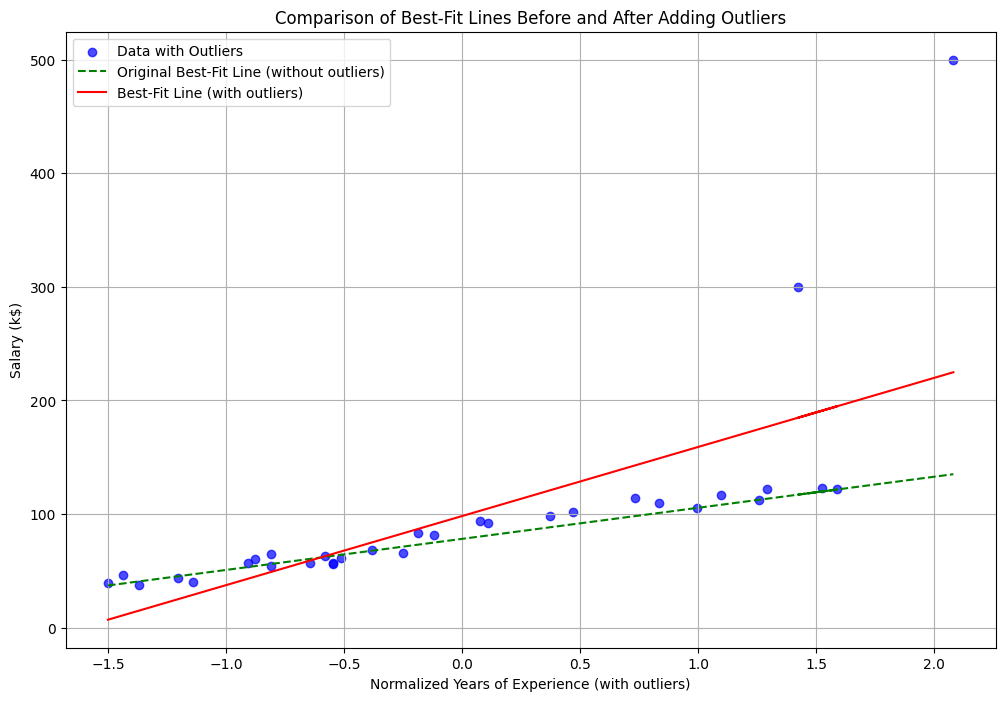

In [ ]:
import matplotlib.pyplot as plt

# 1. Calculate the predicted salary using the original optimized parameters
#    but applied to the outlier-affected normalized experience data.
predicted_salary_original_with_outliers = m * normalized_years_experience_outliers + c_intercept

# 2. Plot the scatter data, including the outliers
plt.figure(figsize=(12, 8))
plt.scatter(normalized_years_experience_outliers, salary_k_outliers, label='Data with Outliers', color='blue', alpha=0.7)

# 3. Overlay the original best-fit line
plt.plot(normalized_years_experience_outliers, predicted_salary_original_with_outliers, color='green', linestyle='--', label='Original Best-Fit Line (without outliers)')

# 4. Overlay the new best-fit line (with outliers)
#    predicted_salary_outliers was calculated in the previous step (cell id 5299b04b)
plt.plot(normalized_years_experience_outliers, predicted_salary_outliers, color='red', label='Best-Fit Line (with outliers)')

# 5. Add appropriate labels for the x and y axes, a title for the plot, and a legend
plt.xlabel('Normalized Years of Experience (with outliers)')
plt.ylabel('Salary (k$)')
plt.title('Comparison of Best-Fit Lines Before and After Adding Outliers')
plt.legend()
plt.grid(True)
plt.show()

The comparison plot clearly illustrates the significant impact of outliers on the linear regression model.

*   **Impact of Outliers**: The **Original Best-Fit Line** (green, dashed) represents the model trained without outliers, showing a reasonable fit to the majority of the data points. However, when the two high-salary outliers are introduced, the **Best-Fit Line with Outliers** (red) is drastically pulled upwards. This shift indicates that the model attempts to minimize the squared error for all points, including the outliers, leading to a compromise. As a result, the new line poorly represents the general trend of the original, non-outlier data. It overpredicts salaries for lower years of experience and is skewed by the extremely high values of the outliers.

*   **Method to Reduce Impact**: One effective method to reduce the impact of outliers in such scenarios is **Robust Regression**. Unlike Ordinary Least Squares (OLS) which minimizes the sum of squared residuals, robust regression methods (e.g., Huber Loss, Tukey's biweight) are designed to be less sensitive to outliers. They assign smaller weights to data points that are far from the fitted line, thus preventing these extreme values from disproportionately influencing the model parameters. Other methods include outlier detection and removal (though this requires careful consideration to avoid removing legitimate data), or using non-linear models if the underlying relationship is not linear.

## Final Task

### Subtask:
Review all deliverables, including code implementation, plots, and written interpretations, ensuring all parts of the assignment have been addressed.


## Summary:

### Data Analysis Key Findings

*   **Initial Model Training and Fit**: Gradient Descent with Backtracking Line Search successfully converged after 100 iterations, yielding an optimized slope ($m$) of approximately 27.35 and an intercept ($c_{intercept}$) of approximately 78.19. The final cost for the initial dataset was 17.58. The best-fit line demonstrated a clear linear relationship with the original data.
*   **Residual Analysis (Initial Model)**: The histogram of residuals for the initial model was roughly centered around zero, indicating that the model did not exhibit strong systematic bias in its predictions.
*   **Backtracking Line Search Behavior**: For both initial learning rates of $\alpha = 1.0$ and $\alpha = 0.1$, the backtracking `while` loop executed exactly 100 times across 100 gradient descent iterations. This implies that the Armijo condition was met on the very first step of the backtracking line search for every iteration in both scenarios, meaning no reduction of the step size (via $\rho$) was necessary.
*   **Impact of Outliers**: The introduction of two high-value outliers (10 years, \$300k and 12 years, \$500k) significantly altered the model.
    *   The optimized parameters shifted dramatically: the slope ($m$) changed from 27.35 to 60.81, and the intercept ($c_{intercept}$) changed from 78.19 to 98.30.
    *   The final cost function value increased substantially from 17.58 to 1988.86, reflecting the model's struggle to fit both the original data and the outliers simultaneously.
    *   The residuals histogram for the outlier-affected model was no longer centered around zero, showing clear bias. The model generally underpredicted for the majority of the original data points while attempting to accommodate the extreme outlier values.
*   **Visual Comparison of Models**: A visual comparison confirmed that the presence of outliers caused the best-fit line to be pulled significantly upwards, resulting in a compromised fit that poorly represented the general trend of the original, non-outlier data.

### Insights or Next Steps

*   **Robustness to Outliers**: The linear regression model, when optimized using standard gradient descent (even with backtracking), is highly sensitive to outliers. When extreme values are present, the model's parameters are skewed, leading to a poor fit for the majority of the data.
*   **Mitigation Strategy**: To address the impact of outliers, consider employing **Robust Regression** techniques (e.g., Huber loss, RANSAC). These methods are designed to be less influenced by extreme data points by assigning smaller weights to outliers or using different loss functions that are less sensitive to large errors. Alternatively, outlier detection and removal can be performed after careful analysis.
